# 1. Setup & Data Loading

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from neuralop.models import FNO

In [2]:
ds = xr.open_dataset("piezo_conductivity.nc", engine="netcdf4")
solution = torch.tensor(ds["solution"].values, dtype=torch.float32)

# 2. Data Audit & Preprocessing

'Min value: -9.805104'

'Max value: 11.139496'

'Mean : 0.020957'

'std : 0.930866'

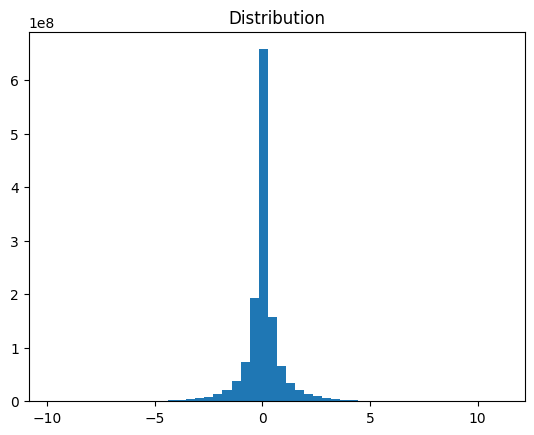

In [3]:
display(
    f"Min value: {solution.min():.6f}",
    f"Max value: {solution.max():.6f}",
    f"Mean : {solution.mean():.6f}",
    f"std : {solution.std():.6f}"
)

plt.hist(solution.flatten().numpy(), bins=50),
plt.title("Distribution")
plt.show()

Всего сэмплов: 4096
Найдено 'плохих' сэмплов: 1
Визуализация примера №4095:


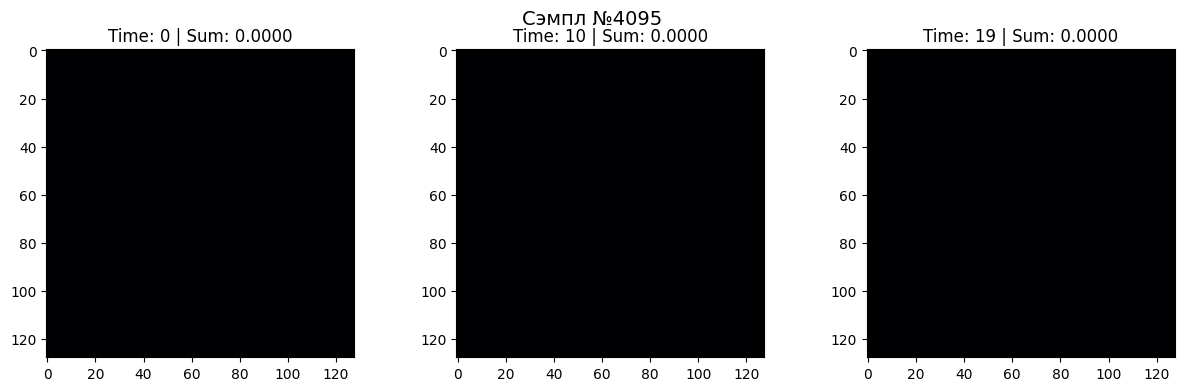

Новая размерность solution: torch.Size([4095, 20, 128, 128])


In [4]:
is_dead = torch.sum(torch.abs(solution), dim=(1, 2, 3)) < 1e-3
bad_indices = torch.where(is_dead)[0].tolist()

print(f"Всего сэмплов: {solution.shape[0]}")
print(f"Найдено 'плохих' сэмплов: {len(bad_indices)}")

if len(bad_indices) > 0:
    idx = bad_indices[0]
    print(f"Визуализация примера №{idx}:")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    times_to_show = [0, solution.shape[1]//2, solution.shape[1]-1]
    
    for i, t in enumerate(times_to_show):
        axes[i].imshow(solution[idx, t].numpy(), cmap='magma')
        axes[i].set_title(f"Time: {t} | Sum: {solution[idx, t].abs().sum():.4f}")
        
    plt.suptitle(f"Сэмпл №{idx}", fontsize=14)
    plt.show()
    
    keep_mask = torch.ones(solution.shape[0], dtype=torch.bool)
    keep_mask[bad_indices] = False
    
    solution = solution[keep_mask]
    print(f"Новая размерность solution: {solution.shape}")

In [5]:
np.random.seed(42)

full_size = solution.shape[0]
selected_indices = np.random.choice(full_size, 1024, replace=False)
train_indices, val_indices, test_indices = selected_indices[:512], selected_indices[512:768], selected_indices[768:]

print(f"Train: {len(train_indices)}\nVal: {len(val_indices)}\nTest: {len(test_indices)}")

Train: 512
Val: 256
Test: 256


In [6]:
class FNODirectDataset(Dataset):

    def __init__(self, solution, sample_indices):
        self.solution = solution[sample_indices]
        self.N, self.T, self.X, self.Y = self.solution.shape
        self.times = torch.linspace(0, 1, self.T)

    def __len__(self):
        return self.N * (self.T - 1)

    def __getitem__(self, idx):
        sample_idx = idx // (self.T - 1)
        t_idx = (idx % (self.T - 1)) + 1

        u_0 = self.solution[sample_idx, 0]
        u_target = self.solution[sample_idx, t_idx]
        time_t = torch.full((self.X, self.Y), self.times[t_idx].item())
        
        input = torch.stack([u_0, time_t], dim=0)

        return input, u_target

# 3. Model Architecture

In [7]:
BATCH_SIZE = 64
EPOCHS = 250

train_loader = DataLoader(FNODirectDataset(solution, train_indices), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(FNODirectDataset(solution, val_indices), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(FNODirectDataset(solution, test_indices), batch_size=BATCH_SIZE, shuffle=False)

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = FNO(
    n_modes=(16, 16),
    in_channels=2,
    out_channels=1,
    hidden_channels=64,
    n_layers=4,
    non_linearity=F.gelu
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# 4. Training & Analysis

In [ ]:
train_losses = []
val_losses_mean = []
val_losses_std = []

best_val_l2 = float('inf') 

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0

    for x_in, u_true in train_loader:
        x_in, u_true = x_in.to(device), u_true.to(device)
        
        optimizer.zero_grad()
        u_pred = model(x_in).squeeze(1)
        
        loss = criterion(u_pred, u_true)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * x_in.size(0)
    
    scheduler.step()
    epoch_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_l2_epoch = []

    with torch.no_grad():
        for x_in, u_true in val_loader:
            x_in, u_true = x_in.to(device), u_true.to(device)
            B = x_in.size(0)

            u_pred = model(x_in).squeeze(1)
            
            preds_flat = u_pred.view(B, -1)
            trues_flat = u_true.view(B, -1)

            num = torch.norm(preds_flat - trues_flat, p=2, dim=1)
            den = torch.norm(trues_flat, p=2, dim=1)
            den = torch.clamp(den, min=1e-8)

            rel_err_percent = (num / den) * 100
            val_l2_epoch.extend(rel_err_percent.cpu().numpy())

    epoch_mean = np.mean(val_l2_epoch)
    epoch_std = np.std(val_l2_epoch)
    
    val_losses_mean.append(epoch_mean)
    val_losses_std.append(epoch_std)

    if epoch_mean < best_val_l2:
        best_val_l2 = epoch_mean
        torch.save(model.state_dict(), 'models/best_fno2d_model.pth')
        save_msg = "💾)"
    else:
        save_msg = ""

    if (epoch + 1) % 5 == 0 or epoch == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train MSE: {epoch_train_loss:.6f} | "
              f"Val L2: {epoch_mean:.2f}% ± {epoch_std:.2f}% | LR: {current_lr:.6e} {save_msg}")

Epoch 001/250 | Train MSE: 0.438546 | Val L2: 25.03% ± 9.15% | LR: 1.999921e-04 💾)
Epoch 005/250 | Train MSE: 0.016961 | Val L2: 14.21% ± 8.35% | LR: 1.998027e-04 💾)
Epoch 010/250 | Train MSE: 0.008390 | Val L2: 9.13% ± 6.57% | LR: 1.992115e-04 💾)
Epoch 015/250 | Train MSE: 0.004052 | Val L2: 8.50% ± 7.37% | LR: 1.982287e-04 💾)
Epoch 020/250 | Train MSE: 0.002271 | Val L2: 10.17% ± 11.04% | LR: 1.968583e-04 
Epoch 025/250 | Train MSE: 0.001569 | Val L2: 6.38% ± 5.50% | LR: 1.951057e-04 
Epoch 030/250 | Train MSE: 0.001394 | Val L2: 4.92% ± 3.21% | LR: 1.929776e-04 💾)
Epoch 035/250 | Train MSE: 0.001298 | Val L2: 4.34% ± 2.59% | LR: 1.904827e-04 💾)
Epoch 040/250 | Train MSE: 0.001240 | Val L2: 9.30% ± 10.59% | LR: 1.876307e-04 
Epoch 045/250 | Train MSE: 0.001301 | Val L2: 4.14% ± 2.66% | LR: 1.844328e-04 💾)
Epoch 050/250 | Train MSE: 0.001206 | Val L2: 10.08% ± 11.88% | LR: 1.809017e-04 
Epoch 055/250 | Train MSE: 0.001126 | Val L2: 4.24% ± 3.03% | LR: 1.770513e-04 
Epoch 060/250 | Tra

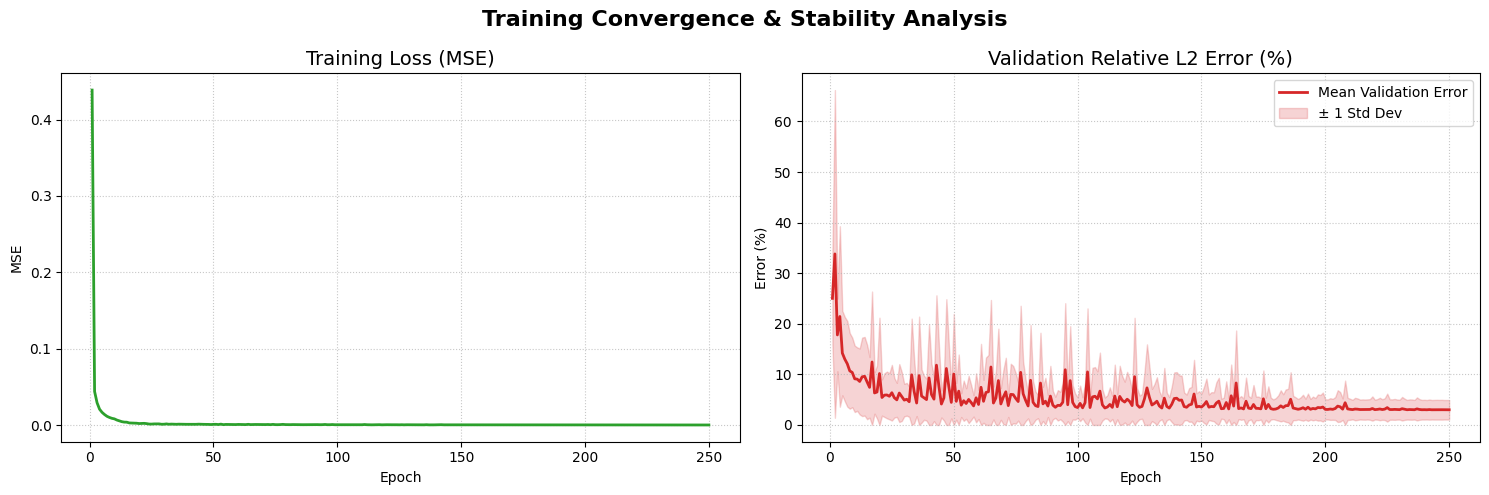

In [ ]:
num_epochs = len(train_losses)
epochs_range = np.arange(1, num_epochs + 1)
mean_arr = np.array(val_losses_mean)
std_arr = np.array(val_losses_std)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Training Convergence & Stability Analysis', fontsize=16, fontweight='bold')

axes[0].plot(epochs_range, train_losses, color='#2ca02c', linewidth=2)
axes[0].set_title('Training Loss (MSE)', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].plot(epochs_range, mean_arr, label='Mean Validation Error', color='#d62728', linewidth=2)
axes[1].fill_between(epochs_range, 
                     np.maximum(0, mean_arr - std_arr),
                     mean_arr + std_arr, 
                     color='#d62728', alpha=0.2, label='± 1 Std Dev')

axes[1].set_title('Validation Relative L2 Error (%)', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Error (%)')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig("assets/convergence_analysis.png", dpi=300)
plt.show()

# 5. Final Evaluation

In [ ]:
model.load_state_dict(torch.load('models/best_model.pth', weights_only=False))

model.eval()

test_l2_errors = []
with torch.no_grad():
    for x_in, u_true in test_loader:
        x_in, u_true = x_in.to(device), u_true.to(device)
        B = x_in.size(0)
        u_pred = model(x_in).squeeze(1)
        
        preds_flat = u_pred.view(B, -1)
        trues_flat = u_true.view(B, -1)
        
        num = torch.norm(preds_flat - trues_flat, p=2, dim=1)
        den = torch.norm(trues_flat, p=2, dim=1)
        den = torch.clamp(den, min=1e-8)
        
        rel_err_percent = (num / den) * 100
        test_l2_errors.extend(rel_err_percent.cpu().numpy())

print(f"Средняя относительная ошибка: {np.mean(test_l2_errors):.2f}%")
print(f"Стандартное отклонение: {np.std(test_l2_errors):.2f}%")

Средняя относительная ошибка: 3.30%
Стандартное отклонение: 1.72%


# 6. Visualization

In [11]:
def create_gif(true_seq, pred_seq, filename="fno_piezo_final.gif"):
    T = true_seq.shape[0]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    vmin, vmax = np.min(true_seq), np.max(true_seq)
    err_max = np.max(np.abs(pred_seq - true_seq)) + 1e-8
    
    im1 = axes[0].imshow(true_seq[0], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0].set_title("Ground Truth", fontsize=14, fontweight='bold')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    im2 = axes[1].imshow(pred_seq[0], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].set_title("Prediction", fontsize=14, fontweight='bold')
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    im3 = axes[2].imshow(pred_seq[0] - true_seq[0], cmap='RdBu_r', vmin=-err_max, vmax=err_max)
    axes[2].set_title("Absolute Error", fontsize=14, fontweight='bold')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
    for ax in axes: ax.set_xticks([]); ax.set_yticks([])
    
    time_text = fig.suptitle(f"Time Step: 0 / {T-1}", fontsize=16, fontweight='bold')

    def update(frame):
        im1.set_array(true_seq[frame])
        im2.set_array(pred_seq[frame])
        im3.set_array(pred_seq[frame] - true_seq[frame])
        
        current_err = np.linalg.norm(pred_seq[frame] - true_seq[frame]) / (np.linalg.norm(true_seq[frame]) + 1e-8) * 100
        
        time_text.set_text(f"Time Step: {frame} / {T-1} | Frame Error: {current_err:.2f}%")
        
        return [im1, im2, im3, time_text]

    ani = animation.FuncAnimation(fig, update, frames=T, interval=250, blit=False)
    ani.save(filename, writer='pillow', fps=4)
    print(f"GIF сохранена: {filename}")
    plt.close()

FileNotFoundError: [Errno 2] No such file or directory: 'data'

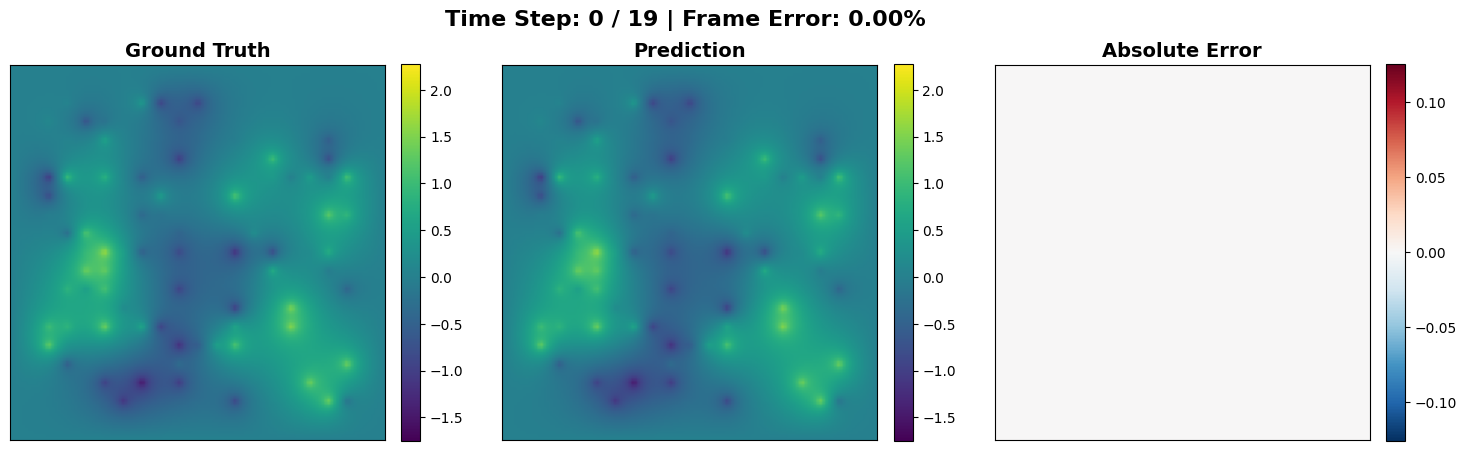

In [ ]:
model.eval()

with torch.no_grad():
    test_sim_idx = test_indices[0]
    true_traj = solution[test_sim_idx].to(device)
    times = torch.linspace(0, 1, true_traj.shape[0]).to(device)
    
    u_0 = true_traj[0]
    preds = [u_0.cpu().numpy()] 
    
    for t_idx in range(1, true_traj.shape[0]):
        time_tensor = torch.full((1, u_0.shape[0], u_0.shape[1]), times[t_idx].item(), device=device)
        x_in = torch.stack([u_0.unsqueeze(0), time_tensor], dim=1)
        u_pred = model(x_in).squeeze(0).squeeze(0)
        preds.append(u_pred.cpu().numpy())
        
    preds = np.array(preds)
    trues = true_traj.cpu().numpy()

create_gif(trues, preds, filename="assets/eval_trajectory.gif")

# 7. Error Distribution

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(test_l2_errors, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Test Errors", fontsize=14)
plt.xlabel("Relative L2 Error (%)")
plt.ylabel("Count")
plt.savefig("assets/error_distribution.png", dpi=300)
plt.show()